# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [766]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Read data

Read geodata with NUTS regions

In [767]:
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

LFS data (pre-processed)

In [768]:
from src.data.lfs import EuLfs

# load config file of EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))

# create object
lfs = EuLfs(config=config)

df_all = lfs.read_preprocessed_file(
    year=2019, input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares"
)

df_all["INCDECIL"] = df_all["INCDECIL"].astype(float)

Subset data for Germany and combine with earnings deciles

In [769]:
df_de = df_all[df_all.COUNTRYW == "DE"]

earnings_deciles_de = pd.read_csv(
    os.path.join(
        useful_paths.data_raw, "metadata", "earnings_distribution_de_2016.csv"
    ),
    delimiter=",",
).astype(float)

df_de = pd.merge(
    df_de, earnings_deciles_de, left_on="INCDECIL", right_on="decil", how="left"
)

Aggregate LFS data by ISCO groups

In [770]:
# Aggregating the shares by their mean yields the same shares because they dont differ within a 3-digit group
agg_dict = {
    "COEFF": np.sum,
    "INCDECIL": np.median,
    "share_green": np.mean,
    "share_brown_sl": np.mean,
    "share_brown_slt": np.mean,
    "share_neutral_sl": np.mean,
    "annual_earnings_2016": np.mean,
}
isco3d_avg_de = df_de.groupby("ISCO3D_label").aggregate(agg_dict)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
isco3d_avg_de["category"] = isco3d_avg_de[
    ["share_green", "share_brown_sl", "share_neutral_sl"]
].idxmax(axis=1)
isco3d_avg_de = isco3d_avg_de.replace(
    to_replace={
        "category": {
            "share_green": "green",
            "share_brown_sl": "brown",
            "share_neutral_sl": "neutral",
        }
    }
)

# Attach the categorical GBN classification to the LFS data
df_de = pd.merge(
    df_de,
    isco3d_avg_de.reset_index()[["ISCO3D_label", "category"]],
    on="ISCO3D_label",
    how="left",
)

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [771]:
%%time

from src.data.framework import Esco

esco = Esco()

# Read occupations with their ISCO level
occ = esco.occupations
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix

# choose OSM version (weighted/unweighted)
osm_version = "weighted"

# read bipartite adjacency matrix for occupations and skills
occ_skills_mat = esco.read_occ_skills_matrix(return_version=osm_version)

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level: average skill vectors
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(
    occ_skills_mat.index.get_level_values(1)
).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(
    occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose()
)

# Find labels for isco codes
isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(str), columns=["code"]),
    esco.isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left",
)

# create index for occ sim matrix
arrays = [
    isco_groups_labels.conceptUri.values,
    isco_groups_labels.preferredLabel.values,
]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# convert to df
df_occ_sims = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)
df_occs = df_occ_sims.index.to_frame().reset_index(drop=True)

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

CPU times: total: 4.09 s
Wall time: 3.86 s


#### Calibrate transition thresholds

In [772]:
# esco-level similarity
occ_sim = np.dot(occ_skills_mat.values, occ_skills_mat.values.transpose())

# calibration levels
occ["esco_5_digit"] = occ.code.str.slice(0, 6)
occ["isco_4_digit"] = occ.iscoGroup

# Create multiindex
arrays = [
    occ.conceptUri.values,
    occ.esco_5_digit.values,
    occ.isco_4_digit.values,
    occ.isco_3_digit.values,
]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(
    tuples, names=["concept_uri", "esco_5_digit", "isco_4_digit", "isco_3_digit"]
)

# occ_sim.index = index
df_occ_sim = pd.DataFrame(index=index, columns=index, data=occ_sim)

In [773]:
# iterate over groups
sim_container = {}

for level in [1, 2, 3]:
    group_res = {}
    for group in df_occ_sim.index.get_level_values(level).values:
        # subset row
        row_subset = df_occ_sim.loc[df_occ_sim.index.get_level_values(level) == group]

        # subset col
        combined_subset = row_subset.loc[
            :, row_subset.columns.get_level_values(level) == group
        ].values.flatten()

        # stats
        mean = combined_subset.mean()
        sd = combined_subset.std()

        # append
        group_res[group] = [mean, sd]

    # append
    sim_container[level] = group_res

In [774]:
df_sim_container = pd.concat(
    {k: pd.DataFrame(v).T for k, v in sim_container.items()}, axis=0
).reset_index()
df_sim_container = df_sim_container.rename(
    columns={"level_0": "level", "level_1": "occupation", 0: "sim_mean", 1: "sim_sd"}
)

level_dict = {1: "esco_5_digit", 2: "isco_4_digit", 3: "isco_3_digit"}
df_sim_container = df_sim_container.replace(to_replace={"level": level_dict})

df_sim_container

,level,occupation,sim_mean,sim_sd
0,esco_5_digit,2654.1,6.03,6.90
1,esco_5_digit,8121.4,21.00,0.00
2,esco_5_digit,7543.1,4.42,7.64
3,esco_5_digit,3155.1,21.00,0.00
4,esco_5_digit,2431.9,20.75,0.00
...,...,...,...,...
2071,isco_3_digit,221,21.81,6.90
2072,isco_3_digit,941,9.92,5.51
2073,isco_3_digit,952,28.50,0.00
2074,isco_3_digit,521,16.25,3.75


#### Plot within-group occupation similarities for different granularity levels
- ESCO 5D
- ISCO 4D
- ISCO 3D

In [775]:
within_group_results = {}
for level in list(level_dict.values()):
    plot_data = df_sim_container[df_sim_container.level == level]

    # calc stats
    within_group_mean = plot_data.sim_mean.mean()
    within_group_sd = plot_data.sim_mean.std()
    within_group_results[level] = [
        within_group_mean,
        within_group_sd,
        within_group_mean - within_group_sd,
    ]

    # plot
    plt.hist(plot_data.sim_mean, bins=20, color="lightgrey")
    # sns.rugplot(data=plot_data, x="sim_mean")

    plt.axvline(within_group_mean, linestyle="--", zorder=1)
    plt.text(
        within_group_mean,
        0,
        "$\mu = {:.2f}$".format(within_group_mean),
        rotation=0,
        va="bottom",
        ha="left",
        fontsize=8,
    )

    plt.grid(linestyle=":")
    plt.xlabel("Skills overlap [-]")
    plt.ylabel("Number of {} groups [-]".format(level))

    sns.despine()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "reskilling_simulation",
            "transition_threshold_calibration",
            "{}.png".format(level),
        ),
        dpi=300,
    )

    plt.cla()
    plt.clf()

<Figure size 432x288 with 0 Axes>

In [776]:
df_within_group_results = pd.DataFrame(
    data=within_group_results, index=["mean", "sd", "mean-sd"]
).T
df_within_group_results.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_simulation",
        "transition_threshold_calibration",
        "within_group_similarities.png",
    )
)
df_within_group_results

,mean,sd,mean-sd
esco_5_digit,22.35,11.55,10.80
isco_4_digit,14.47,10.79,3.68
isco_3_digit,9.06,8.06,1.00


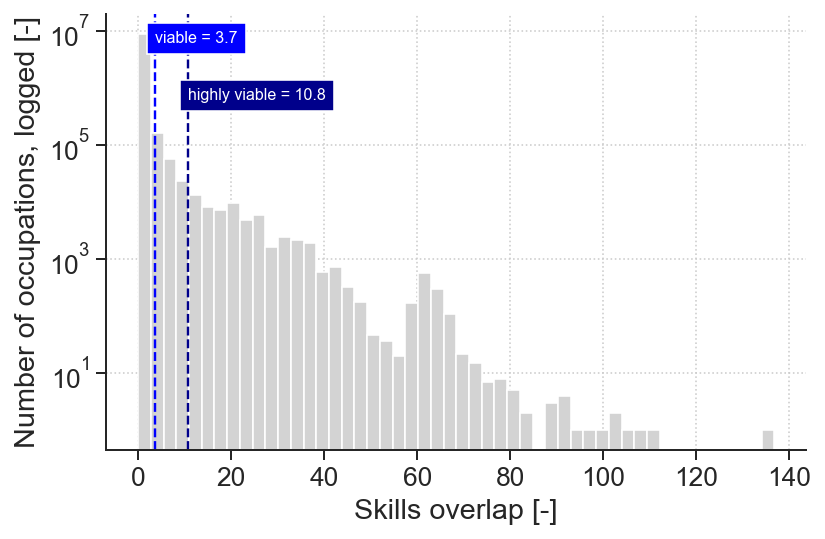

In [777]:
# overview
plt.hist(occ_sim.flatten(), bins=50, log="y", color="lightgrey")
# sns.rugplot(data=occ_sim.flatten())

plt.grid(linestyle=":")
plt.xlabel("Skills overlap [-]")
plt.ylabel("Number of occupations, logged [-]")

# annotate
viable = df_within_group_results.loc["isco_4_digit", "mean-sd"]
plt.axvline(viable, linestyle="--", zorder=1, color="blue")
plt.text(
    viable,
    10e6,
    "viable = {:.1f}".format(viable),
    rotation=0,
    va="top",
    ha="left",
    fontsize=8,
    color="white",
    bbox=dict(facecolor="blue", alpha=1),
)

highly_viable = df_within_group_results.loc["esco_5_digit", "mean-sd"]
plt.axvline(highly_viable, linestyle="--", zorder=1, color="darkblue")
plt.text(
    highly_viable,
    10e5,
    "highly viable = {:.1f}".format(highly_viable),
    rotation=0,
    va="top",
    ha="left",
    fontsize=8,
    color="white",
    bbox=dict(facecolor="darkblue", alpha=1),
)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_simulation",
        "transition_threshold_calibration",
        "overview_of_thresholds.png",
    ),
    dpi=300,
)

Attach averages from LFS data

In [778]:
# merge to df
df_occs_metadata = pd.merge(
    df_occs,
    isco3d_avg_de.reset_index(),
    left_on="occ",
    right_on="ISCO3D_label",
    how="left",
).drop(["ISCO3D_label"], axis=1)

Plot occ sim matrix at ISCO 3 digit level

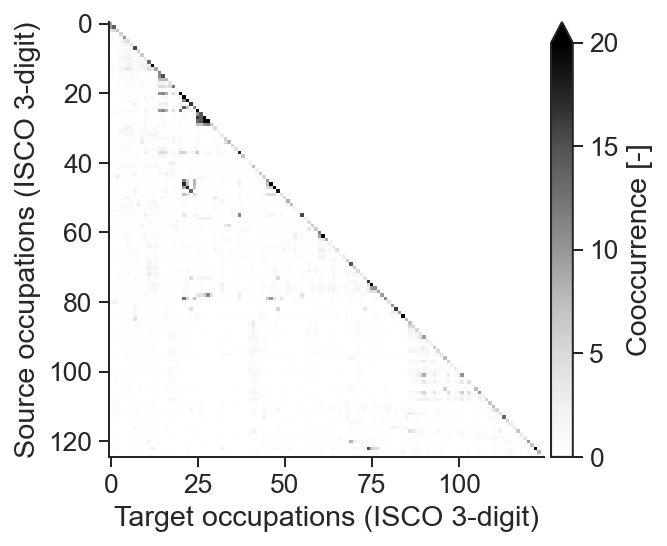

In [779]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots()
im = ax.imshow(np.tril(df_occ_sims.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(
    im, cax=cax, orientation="vertical", label="Cooccurrence [-]", extend="max"
)
ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

Viable/highly viable transitions
- Mining and mineral processing plant operators: 0
- Manufacturing, mining, construction, and distr: 2
- Mining, manufacturing and construction supervi: 1
- Mining and construction labourers: 8


Percentiles of overall distribution

In [780]:
q_viable = np.percentile(df_occ_sims.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.616368047779022 6.500853535353546


Self-calibrated

In [781]:
# q_viable, q_highly_viable = df_within_group_results.loc["isco_4_digit", "mean-sd"], df_within_group_results.loc["esco_5_digit", "mean-sd"]
print(q_viable, q_highly_viable)

1.616368047779022 6.500853535353546


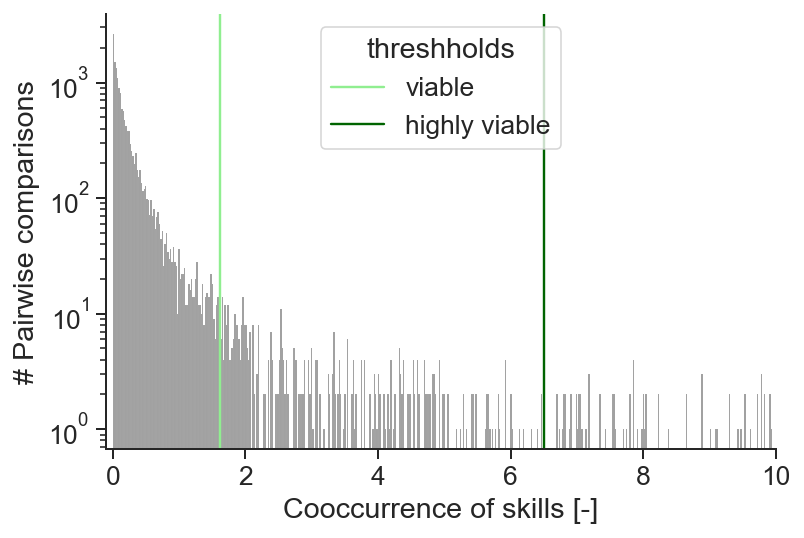

In [782]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

Plot Occupation similarity matrix classified viable/highly viable

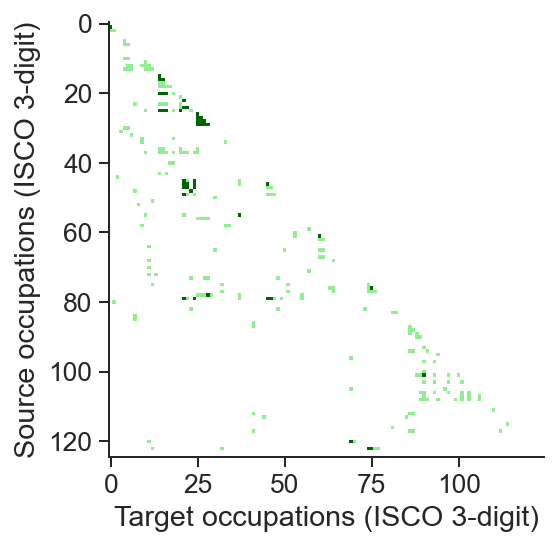

In [783]:
similarity_matrix_classified = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix_classified, 0)

similarity_matrix_classified[similarity_matrix_classified < q_viable] = 0
similarity_matrix_classified[
    (similarity_matrix_classified >= q_viable)
    & (similarity_matrix_classified < q_highly_viable)
] = 1
similarity_matrix_classified[similarity_matrix_classified >= q_highly_viable] = 2

from matplotlib import colors

fig, ax = plt.subplots()

# make a color map of fixed colors
cmap = colors.ListedColormap(["white", "lightgreen", "darkgreen"])
bounds = [0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(np.tril(similarity_matrix_classified), cmap=cmap, norm=norm)

ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

#### Manually check some transitions

In [784]:
occ = df_occs.loc[df_occs.occ == "Mining and construction labourers"]
print(occ.occ)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)

117    Mining and construction labourers
Name: occ, dtype: object


,occ_uri,occ,similarity
86,http://data.europa.eu/esco/isco/C711,Building frame and related trades workers,4.19
87,http://data.europa.eu/esco/isco/C712,Building finishers and related trades workers,3.34
112,http://data.europa.eu/esco/isco/C834,Mobile plant operators,3.05
41,http://data.europa.eu/esco/isco/C312,"Mining, manufacturing and construction supervi...",2.41
94,http://data.europa.eu/esco/isco/C741,Electrical equipment installers and repairers,1.42


#### Transition pools (at-risk jobs)

- MSc thesis: coal-related occupations
- Paper: ?

Paper: Brown occupations
- v1: with dominant share (> 50%)
- v2: above threshold
- v3: all with share > 0

In [785]:
df_transition_pool_core_brown = df_de.loc[df_de.category == "brown"]
df_transition_pool_core_brown.COEFF.sum()

892402.4875

Share-based: above mean of sl or slt

In [786]:
df_transition_pool_aboveavg_brown_sl = df_de.loc[
    df_de["share_brown_sl"] > isco3d_avg_de["share_brown_sl"].mean()
]
df_transition_pool_aboveavg_brown_sl.COEFF.sum()

6830519.8100000005

In [787]:
df_transition_pool_aboveavg_brown_slt = df_de[
    df_de["share_brown_slt"] > isco3d_avg_de["share_brown_slt"].mean()
]
df_transition_pool_aboveavg_brown_slt.COEFF.sum()

8419473.565

MSc thesis: coal-related occupations

In [788]:
dict_transition_pool_thesis = {
    "Mining, manufacturing and construction supervisors": "312",
    "Mining and mineral processing plant operators": "811",
    "Manufacturing, mining, construction, and distribution managers": "132",
    "Mining and construction labourers": "931",
}

industries = [
    "Electricity, Gas, Steam and Air Conditioning Supply",
    "Mining and Quarrying",
]

cond_occupation = df_de.ISCO3D_label.isin(list(dict_transition_pool_thesis.keys()))
cond_industry = df_de.NACE1D_label.isin(industries)

df_transition_pool_thesis = df_de.loc[cond_occupation & cond_industry]

Store options in dict

In [789]:
transition_pool_options = {
    "coal": df_transition_pool_thesis,
    "brown": df_transition_pool_core_brown,
    "aboveavg_brown_sl": df_transition_pool_aboveavg_brown_sl,
    "aboveavg_brown_slt": df_transition_pool_aboveavg_brown_slt,
}

### Analyse number of viable transitions

#### Parameters

In [790]:
from src import plotting_utils

# colorbars
cmap_earnings = plt.get_cmap("coolwarm_r", 8)
cmap_earnings.set_over("darkblue")
cmap_earnings.set_under("darkred")

#cmap_transitions = plotting_utils.discrete_cmap_with_manual_colors(cmap_type="Blues", n_classes=5)
cmap_transitions = plt.get_cmap("Blues", 10)
cmap_transitions.set_over("darkblue")

# upper limits for colorbars
vmax_transitions = 10  # n viable transitions
vmax_wages = 40  # million euro

# initialise dict to store estimates of total wage changes
earnings_losses = {}

# choice of source transition pool
transition_pool = "aboveavg_brown_sl"
df_transition_pool = transition_pool_options[transition_pool]

# choice of weights for transition pool of search occupation: COEFF > COEFF_share_brown_sl > COEFF_share_brown_slt
transition_pool_weights = "COEFF_share_brown_sl"

# remedy from  thesis
run_skills_continuity_scenarios = False

# create results dir
out_dirname = "{}_occupations_by_{}".format(
    transition_pool, transition_pool_weights.lower()
)
out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation", out_dirname)
utils.ccdir(out_dir)

In [791]:
# populate transition pool dict
transition_pool_dict = {}
for i, s in df_transition_pool.iterrows():
    transition_pool_dict[s.ISCO3D_label] = s.ISCO3D

Number of transitioning workers

In [792]:
df_transition_pool.groupby("NACE1D_label").sum().iloc[:, :4].to_csv(
    os.path.join(out_dir, "source_transition_pool.csv")
)

PermissionError: [Errno 13] Permission denied: '\\\\gess-fs.d.ethz.ch\\home$\\fzaussinger\\Documents\\Projects\\04_jrc_green-skills-regional\\03_data-analysis\\re4gt\\results\\figures\\reskilling_simulation\\aboveavg_brown_sl_occupations_by_coeff_share_brown_sl\\source_transition_pool.csv'

#### Scenario 1: Workers follow closest viable transition regardless of earnings losses (Skills continuity scenario)

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []
    for i, search_obs in df_transition_pool.iterrows():

        search_label = search_obs.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        target_occs = find_closest(
            i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
        )

        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016
                * (-1)
                * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None

        transition_number_data.append(search_obs)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # plot
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )

    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.axis("off")
    plt.tight_layout()

    # sum of transitions
    cmap = plt.get_cmap("Blues", 6)
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        legend_kwds={"label": "Viable transitions [-]", "fraction": 0.03},
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )
    plt.tight_layout()
    ax.axis("off")

    # earnings changes
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario")
    ax.axis("off")
    plt.tight_layout()

    # append aggregate
    earnings_losses[
        "skills_continuity"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()
    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### At-risk metric

risk = 1 / n_viable_transitions * n_at_risk_jobs

if n_viable_transitions = 0, ratio is set to 1

In [ ]:
if run_skills_continuity_scenarios:
    gdf_transition_numbers_by_nuts["risk_indicator"] = (
        1 / gdf_transition_numbers_by_nuts.n_viable_transitions
    ).replace([np.inf, -np.inf], 1) * gdf_transition_numbers_by_nuts[
        transition_pool_weights
    ]

    cmap = plt.get_cmap("Blues", 8)
    ax = gdf_transition_numbers_by_nuts.plot(
        column="risk_indicator",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=50,
        legend_kwds={"label": "Jobs at risk [-]", "fraction": 0.03},
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )
    plt.tight_layout()
    ax.axis("off")

#### Scenario 2: Workers follow viable transition that minimises earnings losses (wage continuity scenario)

In [ ]:
%%time
transition_number_data = []

for i, search_obs in tqdm(df_transition_pool.iterrows()):
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    target_occs = find_closest(
        i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
    )

    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[
        target_occs_filtered.category != "brown"
    ]
    target_occs_filtered = target_occs_filtered.dropna()

    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = (
        target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    )

    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        )
        search_obs["earnings_delta_closest_switch_sum"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        ) * search_obs[transition_pool_weights]
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = (
            target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
        )
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
        search_obs["target_category"] = target.category.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs[
            "earnings_delta_closest_switch"
        ] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = (
            search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
        )
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
        search_obs["target_category"] = None

    transition_number_data.append(search_obs)

# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# scale
df_transition_numbers["earnings_delta_closest_switch_sum_mio"] = (
    df_transition_numbers["earnings_delta_closest_switch_sum"] / 10**6
)

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_by_nuts[transition_pool_weights]
)

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

##### Regional distribution of transition pathways

In [ ]:

ax = gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, out_dir, "n_transitions_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

In [ ]:
v = vmax_wages

ax = gdf_transition_numbers_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€~(2010)$".format(
        gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (mean/median)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Comparison of costs with Kohleaustiegsbudget

In [ ]:
earnings_losses[
    "wage_continuity"
] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [ ]:
df_top_skills_per_occ_all = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_5_skills_per_isco3d_occupation.csv",
    ),
    index_col=0,
)

# subset brown occupations
df_top_skills_per_occ = df_top_skills_per_occ_all[
    df_top_skills_per_occ_all.Occupation.isin(list(transition_pool_dict.keys()))
]

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [ ]:
isco_group_dict = dict(zip(isco_groups_labels.preferredLabel, isco_groups_labels.code))

In [ ]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]

    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)

df_optimal_upskilling_per_occ = pd.concat(
    optimal_upskilling_per_occ, axis=0
).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(
        columns={"preferredLabel": "Skill", "index": "id_skill"}
    ),
    on="Skill",
)

df_optimal_upskilling_per_occ["id_occ"] = [
    isco_group_dict[occ_label]
    for occ_label in df_optimal_upskilling_per_occ.Occupation.values
]

df_optimal_upskilling_per_occ.to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_selected_skill_per_occupation.csv",
    )
)
df_optimal_upskilling_per_occ

In [ ]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [ ]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

In [ ]:
occ = df_optimal_upskilling_per_occ.iloc[0]

# find index of occ
idx_occ = occ_codes.index(occ.id_occ)
idx_new_skill = occ.id_skill

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(
    occ_skills_mat_isco3_upskilling.values,
    occ_skills_mat_isco3_upskilling.values.transpose(),
)
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

#### 1) Skills continuity scenario with upskilling

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []

    for i, search_obs in tqdm(df_transition_pool.iterrows()):

        search_label = search_obs.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        # -----------------------------------------------------------------------------------------------------------------------------
        # UPSKILLING STEP
        # -----------------------------------------------------------------------------------------------------------------------------
        # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
        upskilling_data = df_optimal_upskilling_per_occ.loc[
            df_optimal_upskilling_per_occ.Occupation == search_label
        ]

        # find index of occ
        idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
        idx_new_skill = upskilling_data.id_skill

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(
            occ_skills_mat_isco3_upskilling.values,
            occ_skills_mat_isco3_upskilling.values.transpose(),
        )
        np.fill_diagonal(occ_sims_isco3_upskilling, 0)

        # find closest transitions
        target_occs = find_closest(
            i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
        )

        # filter
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
            search_obs["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016
                * (-1)
                * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None
            search_obs["target_category"] = None

        transition_number_data.append(search_obs)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # PLOTS

    # TRANSITION NUMBERS
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    # ax.set_title("Viable transitions (upskilling)")
    ax.axis("off")

    # EARNINGS LOSSES
    cmap = plt.get_cmap("RdYlGn")
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario (upskilling)")
    ax.axis("off")
    plt.tight_layout()

    # totals
    earnings_losses[
        "skills_continuity_upskilling"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### 2) Wage continuity scenario with upskilling

In [ ]:
transition_number_data_upskilling = []

for i, search_obs in tqdm(df_transition_pool.iterrows()):
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[
        df_optimal_upskilling_per_occ.Occupation == search_label
    ]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(
        occ_skills_mat_isco3_upskilling.values,
        occ_skills_mat_isco3_upskilling.values.transpose(),
    )
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)

    # find closest transitions
    target_occs = find_closest(
        i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
    )

    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[
        target_occs_filtered.category != "brown"
    ]
    target_occs_filtered = target_occs_filtered.dropna()

    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = (
        target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    )

    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        )
        search_obs["earnings_delta_closest_switch_sum"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        ) * search_obs[transition_pool_weights]
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = (
            target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
        )
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
        search_obs["target_category"] = target.category.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs[
            "earnings_delta_closest_switch"
        ] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = (
            search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
        )
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
        search_obs["target_category"] = None

    transition_number_data_upskilling.append(search_obs)

# to df
df_transition_numbers_upskilling = pd.concat(transition_number_data_upskilling, axis=1).T
df_transition_numbers_upskilling = df_transition_numbers_upskilling.infer_objects()

# scale
df_transition_numbers_upskilling["earnings_delta_closest_switch_sum_mio"] = (
    df_transition_numbers_upskilling["earnings_delta_closest_switch_sum"] / 10**6
)

# Calculate avg number of transitions per threatened job
df_transition_numbers_upskilling_by_nuts = df_transition_numbers_upskilling.groupby("NUTS_ID").sum()
df_transition_numbers_upskilling_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_upskilling_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_upskilling_by_nuts[transition_pool_weights]
)

# to gdf
gdf_transition_numbers_upskilling_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_upskilling_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

##### Regional distribution of transition pathways

In [ ]:
ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_upskilling_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "n_transitions_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

In [ ]:
v = vmax_wages

ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€$".format(
        gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.sum()

##### Sectoral distribution of earnings changes (mean/median)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers_upskilling,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
earnings_losses[
    "wage_continuity_upskilling"
] = gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)

### Comparison of earnings losses across scenarios

In [ ]:
df_earnings_losses = pd.DataFrame.from_dict(
    earnings_losses, orient="index", columns=["annual_earnings_delta"]
)
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.reset_index()
wage_scenario["annual_earnings_delta_mio"] = wage_scenario["annual_earnings_delta"] / 10**6

In [ ]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2010)]")

plt.xticks(np.arange(2), ["Before", "After"])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
    orient="h",
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2010)]")

plt.yticks(np.arange(2), ["Before", "After"])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Pension in Germany with 67 years

In [ ]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_mio_15yrs"] = wage_scenario.annual_earnings_delta_mio * age_delta
wage_scenario